# Import

In [1]:
from parcels import (
        FieldSet,
        JITParticle,
        ScipyParticle,
        ParticleSet,
        AdvectionRK4,
        AdvectionRK4_3D,
        StatusCode,
)
import parcels

import datetime as dt
from datetime import datetime, timedelta

import dask

import numpy as np
from numpy.random import uniform, randint

from pathlib import Path
import geopandas as gpd
import pandas as pd

import seaborn as sns

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.colors as mcolors
import cmocean

import xarray as xr
from glob import glob
import cartopy
import cartopy.crs as ccrs
from time import time
import warnings
import shapely
import itertools

warnings.simplefilter("ignore")

# Set Parameters

In [2]:
zarr_path = Path("/gxfs_work/geomar/smomw597/2025_Fucus/output/Trajectories/2021/TEST_Fucus_BSH_20210101-20210129_dt60min_N43600_seed123.zarr")
# zarr_path = Path("/gxfs_work/geomar/smomw597/2025_Fucus/output/Trajectories/2021/TEST_Nested_20210101-20210108_dt60min_N500_seed123.zarr")
zarr_path = Path("/gxfs_work/geomar/smomw597/2025_Fucus/output/Trajectories/2023/Fucus_BSH_20230701-20231230_dt60min_N235440_seed123.zarr")
ds_trajectories = xr.open_zarr(zarr_path)#.compute()
ds_trajectories

<xarray.Dataset> Size: 50GB
Dimensions:     (trajectory: 235440, obs: 5304)
Coordinates:
  * obs         (obs) int32 21kB 0 1 2 3 4 5 6 ... 5298 5299 5300 5301 5302 5303
  * trajectory  (trajectory) int64 2MB 0 1 2 3 4 ... 235436 235437 235438 235439
Data variables:
    age_sec     (trajectory, obs) float32 5GB dask.array<chunksize=(235440, 24), meta=np.ndarray>
    cell_ID     (trajectory, obs) float32 5GB dask.array<chunksize=(235440, 24), meta=np.ndarray>
    lat         (trajectory, obs) float64 10GB dask.array<chunksize=(235440, 24), meta=np.ndarray>
    lon         (trajectory, obs) float64 10GB dask.array<chunksize=(235440, 24), meta=np.ndarray>
    time        (trajectory, obs) datetime64[ns] 10GB dask.array<chunksize=(235440, 24), meta=np.ndarray>
    z           (trajectory, obs) float64 10GB dask.array<chunksize=(235440, 24), meta=np.ndarray>
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        NewParticleAdvectionRK4_2D_SIGMABSHaging_kernel
    parcels_mesh:           spherical
    parcels_version:        3.0.6

In [3]:
release_area_path = Path("/gxfs_work/geomar/smomw597/2025_Fucus/2025_fucus-dispersal/Fucus_location_shp")
gdf_release_area = gpd.read_file(Path(release_area_path, "REDLIST_SIS_Macrophytes.geojson"))
gdf_release_area = gdf_release_area.loc[
        (gdf_release_area.F_vesiculo != 0).values, 
        ["geometry", "CELLCODE"],]

In [4]:
subbasins_lvl2_path = Path("/gxfs_work/geomar/smomw597/2025_Fucus/2025_fucus-dispersal/HELCOM_subbasins_2022_level2")
gdf_subbasins_area = gpd.read_file(Path(subbasins_lvl2_path, "HELCOM_subbasins_2022_level2.shp"))
gdf_subbasins_area = gdf_subbasins_area.to_crs(crs=ccrs.Geodetic())

In [5]:
try: ds_trajectories = ds_trajectories.rename(dict(CellID="cell_ID"))
except: ds_trajectories

In [6]:
release_centroid = gpd.GeoDataFrame(gdf_release_area.CELLCODE, geometry=gdf_release_area.geometry.centroid)
gdf_release_area = gpd.sjoin_nearest(
        left_df=release_centroid, 
        right_df=gdf_subbasins_area, 
        how="left", 
        rsuffix="basin_",
)[["CELLCODE", "level_2", "geometry"]]

In [7]:
try: list_cell_ID = ds_trajectories.cell_ID.isel(obs=0).values.astype(int)
except: ""

In [8]:
# https://github.com/Yichabod/natural_disaster_pred/blob/master/cropping_coordinates.py

earth_radius = 6271.0
degrees_to_radians = np.pi / 180.0
radians_to_degrees = 180.0 / np.pi

def dlat_to_dkm(dlat):
        return dlat * earth_radius * degrees_to_radians
def dlon_to_dkm(latitude, dlon):
        r = earth_radius * np.cos(np.multiply(latitude, degrees_to_radians))
        return dlon * r * degrees_to_radians

In [9]:
dlat = ds_trajectories.lat.diff(dim="obs").interp_like(ds_trajectories.lat)
dlon = ds_trajectories.lon.diff(dim="obs").interp_like(ds_trajectories.lat)
lats = ds_trajectories.lat - dlat / 2

distance = (dlat_to_dkm(dlat)**2 + dlon_to_dkm(lats, dlon)**2)**.5
cumulative_distance = distance.cumsum(dim="obs")
total_distance = distance.sum(dim="obs")

In [10]:
distance = distance.assign_attrs(dict(
        long_name="Distance traveled in kilometers",
        standard_name="Distance",
        units="km",
))
cumulative_distance = cumulative_distance.assign_attrs(dict(
        long_name="Cumulated distance traveled in kilometers",
        standard_name="Cumulated Distance",
        units="km",
))
total_distance = total_distance.assign_attrs(dict(
        long_name="Total distance traveled in kilometers",
        standard_name="Total Distance",
        units="km",
))

In [11]:
release_dates = ds_trajectories.time.where("obs"==0, ds_trajectories.time.isel(obs=0))
valid_obs_count = ds_trajectories.lat.notnull().sum(dim="obs", skipna=True)

In [12]:
last_valid_obs = ds_trajectories.obs.where(ds_trajectories.lon.notnull()).max('obs').astype(int).compute()
last_step = ds_trajectories.isel(obs=last_valid_obs).compute()

first_lat = ds_trajectories.isel(obs=0).lat.compute()
first_lon = ds_trajectories.isel(obs=0).lon.compute()

last_lon = last_step.lon.compute()
last_lat = last_step.lat.compute()

# last_step.to_dataframe()[["lat", "lon", "lat_diff", "lon_diff", "obs", "release_date", "age_sec"]].describe()

In [13]:
traj_dead = ds_trajectories.where(first_lon == last_lon, drop=True)
traj_moving = ds_trajectories.where(first_lon != last_lon, drop=True)
# ds_trajectories = ds_trajectories.where(first_lon != last_lon, drop=True)

In [14]:
lon_diff = last_lon - first_lon
lat_diff = last_lat - first_lat

In [15]:
ds_trajectories = ds_trajectories.assign(
        distance=distance,
        cumulative_distance=cumulative_distance,
        total_distance=total_distance,
        release_date=release_dates,
        valid_obs_count=valid_obs_count,
        lat_diff=lat_diff,
        lon_diff=lon_diff,
)

In [16]:
cell_codes = gdf_release_area.loc[list_cell_ID].CELLCODE.values.flatten().astype(str)
subbasins = gdf_release_area.loc[list_cell_ID].level_2.values.flatten().astype(str)
trajectories = ds_trajectories.trajectory.values
multi_idx_traj_cellID = pd.MultiIndex.from_arrays(
        arrays=[trajectories, list_cell_ID, subbasins, ],
        names=("trajectory_ID", "cell_ID", "subbasin",),
)
traj_coords = xr.Coordinates.from_pandas_multiindex(multi_idx_traj_cellID, "trajectory")

age_sec_obs = ds_trajectories.age_sec.max(dim="trajectory", skipna=True).values

In [17]:
ds_trajectories = ds_trajectories.assign(dict(
        # traj_coords,
        cell_code=("trajectory", cell_codes),
        age_sec_obs=("obs", age_sec_obs),
        subbasin=("trajectory", subbasins),
        cell_ID=("trajectory", list_cell_ID),
        # trajectory_ID=("trajectory", trajectories),
))

In [18]:
ds_trajectories = ds_trajectories.where(traj_moving.trajectory)

In [32]:
np.mean((lon_min, lon_max))

18.5

In [33]:
lon_min, lon_max = (5,32)
lat_min, lat_max = (53,66)
central_longitude = np.mean((lon_min, lon_max))
central_latitude = np.mean((lat_min, lat_max))
lon_range = lon_max-lon_min
lat_range = lat_max-lat_min

In [20]:
from xhistogram.xarray import histogram as xhist


In [21]:
def calc_hist_0(ds, lon_bins, lat_bins, dims=["trajectory"]):
        return xhist(
                ds.lon, ds.lat,
                bins=[lon_bins, lat_bins],
                dim=dims,
        ).rename(dict(lon_bin="lon",lat_bin="lat"))

In [22]:
def calc_hist_1(ds, lon_bins, lat_bins, dims=["trajectory"], weights=None):
        return (
                xhist(
                        ds.lon, ds.lat,
                        bins=[lon_bins, lat_bins],
                        dim=dims,
                        weights=weights,
                ).rename(dict(lon_bin="lon",lat_bin="lat")) 
                / calc_hist_0(ds, lon_bins, lat_bins, dims)
        )

In [23]:
# sinnvolle cmap (1D, dichte visualisiert)
ds_plot_0 = np.log10(
        ds_trajectories.groupby("subbasin").apply(
                lambda ds: 
                calc_hist_0(
                        ds,
                        np.linspace(lon_min, lon_max, 120),
                        np.linspace(lat_min, lat_max, 120),
                        dims=["trajectory", "obs"],
                )
        )
).compute()

In [24]:
# sinnvolles vmin vmax, 
# sinnvolle cmap (1D, dichte visualisiert)
ds_plot_1 = ds_trajectories.groupby("subbasin").apply(
        lambda ds: 
        calc_hist_1(
                ds,
                np.linspace(lon_min, lon_max, 120),
                np.linspace(lat_min, lat_max, 120),
                dims=["trajectory", "obs"],
                weights=ds.obs,
        )
).compute()

In [25]:
subbasins_simple = gdf_subbasins_area.set_index("level_2").geometry.buffer(0.2).buffer(-0.2).exterior

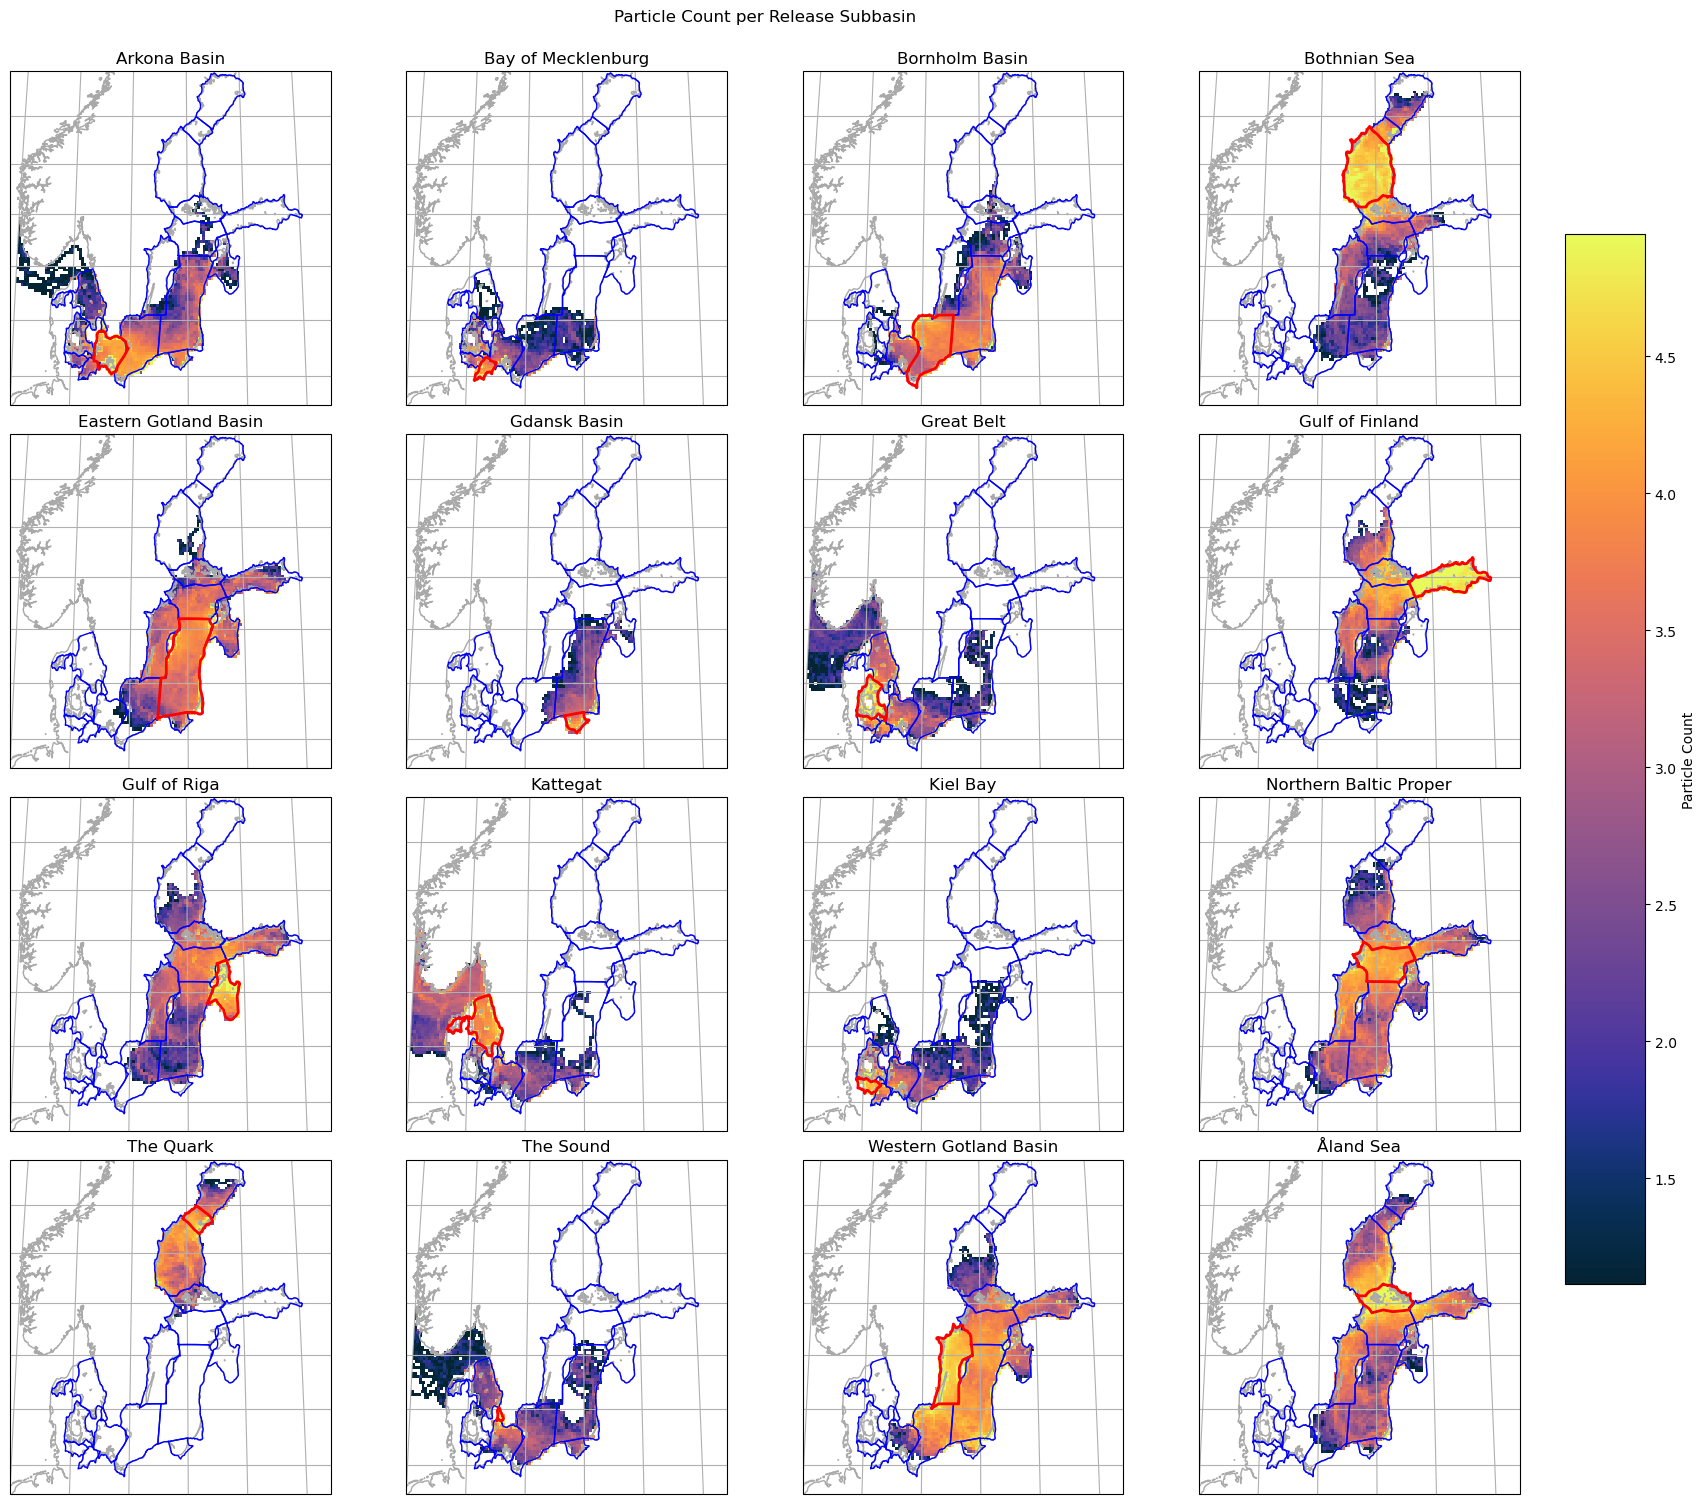

In [43]:
vmin, vmax = list(ds_plot_0.where(ds_plot_0.notnull() & ~np.isinf(ds_plot_0)).quantile([0.05, 0.95]))

fig, axes = plt.subplots(
        figsize=(16, 15),
        nrows=4, ncols=4, 
        sharex=True, sharey=True, 
        subplot_kw=dict(projection=ccrs.EckertIV(central_longitude=central_longitude,)), 
)

fig.suptitle("Particle Count per Release Subbasin", y=1)
for ax, basin in zip(axes.flatten(), ds_plot_0.subbasin.values):
        subbasins_simple.plot(ax=ax, transform=ccrs.Geodetic(), color="b", lw=1, zorder=10,)
        ax.plot(*subbasins_simple.loc[basin].xy, transform=ccrs.PlateCarree(), color="r", lw=2, zorder=30,)
        im = ds_plot_0.sel(subbasin=basin).plot.pcolormesh(
                x="lon", y="lat", ax=ax, 
                vmin=vmin, vmax=vmax, 
                cmap=cmocean.cm.thermal,
                add_colorbar=False, transform=ccrs.PlateCarree(),
        )
        ax.set_title(basin)
        ax.coastlines(color="darkgrey")
        ax.gridlines(draw_labels=False)
        ax.set_extent((lon_min, lon_max, lat_min, lat_max))

fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([1., 0.15, 0.05, 0.7])
fig.colorbar(im, cax=cbar_ax, label="Particle Count")
fig.tight_layout()
plt.show()

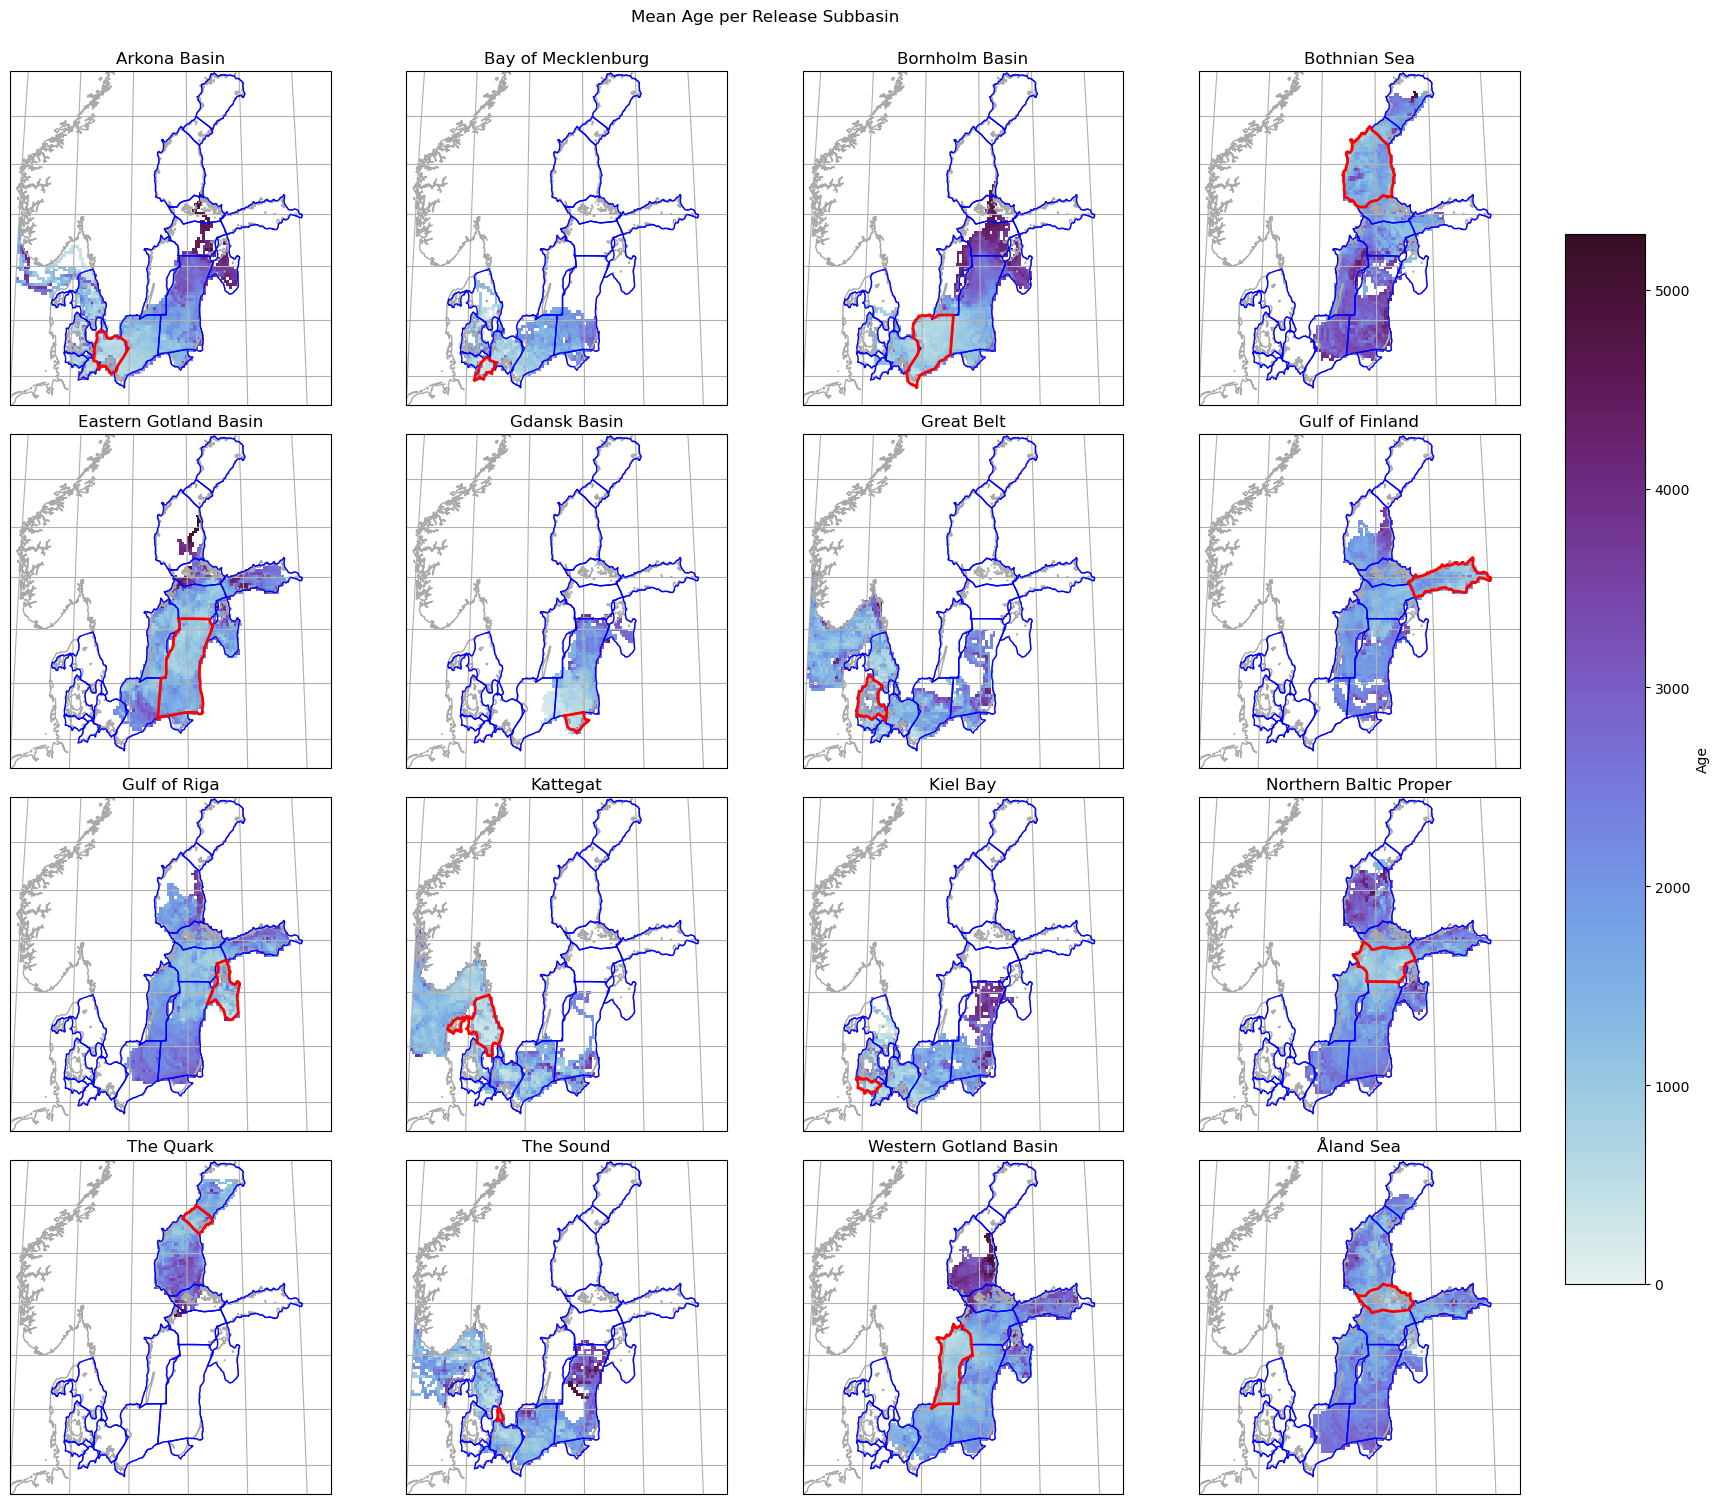

In [42]:
vmin = 0
vmax = 220*24
fig, axes = plt.subplots(
        figsize=(16, 15),
        nrows=4, ncols=4, 
        sharex=True, sharey=True, 
        subplot_kw=dict(projection=ccrs.EckertIV(central_longitude=central_longitude,)), 
)

fig.suptitle("Mean Age per Release Subbasin", y=1)
for ax, basin in zip(axes.flatten(), ds_plot_1.subbasin.values):
        subbasins_simple.plot(ax=ax, transform=ccrs.Geodetic(), color="b", lw=1, zorder=10,)
        ax.plot(*subbasins_simple.loc[basin].xy, transform=ccrs.PlateCarree(), color="r", lw=2, zorder=30,)
        im = ds_plot_1.sel(subbasin=basin).plot.pcolormesh(
                x="lon", y="lat", ax=ax, 
                cmap=cmocean.cm.dense,
                vmin=vmin, vmax=vmax, 
                add_colorbar=False, transform=ccrs.PlateCarree(),
        )
        ax.set_title(basin)
        ax.coastlines(color="darkgrey")
        ax.gridlines(draw_labels=False)
        ax.set_extent((lon_min, lon_max, lat_min, lat_max))

fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([1., 0.15, 0.05, 0.7])
fig.colorbar(im, cax=cbar_ax, label="Age")
fig.tight_layout()
plt.show()

statistics of in which month and from which starting position do the particles travel how far, and the area

In [45]:
def calc_dist_quantiles(ds):
        dist = 111e3 * (
                ((ds[["lon", "lat"]] - ds.isel(obs=0, drop=True)[["lon", "lat"]]) ** 2).to_array() 
                * xr.DataArray([np.cos(np.deg2rad(60)),1], dims="variable")
        ).sum(dim="variable")**0.5
        return dist.where(ds.lon.notnull()).quantile(np.linspace(0,1,5), dim="trajectory").rename("dist")

In [46]:
def calc_dist_mean(ds):
        dist = 111e3 * (
                ((ds[["lon", "lat"]] - ds.isel(obs=0, drop=True)[["lon", "lat"]]) ** 2).to_array() 
                * xr.DataArray([np.cos(np.deg2rad(60)),1], dims="variable")
        ).sum(dim="variable")**0.5
        return dist.where(ds.lon.notnull()).mean(dim="trajectory").rename("dist")

In [47]:
df_distance_q = ds_trajectories.groupby("subbasin").apply(calc_dist_quantiles).compute().to_dataframe()

In [ ]:
# df_distance_q.unstack(0).loc[0.5].assign(time=np.timedelta64(1, "h")*np.arange(5304)).set_index("time", drop=True).resample("5D").max()["dist"].plot()


In [48]:
df_distance_m = ds_trajectories.groupby("subbasin").apply(calc_dist_mean).compute().to_dataframe()
df_distance_m = df_distance_m.unstack(0).assign(time=np.timedelta64(1, "h")*np.arange(5304)).set_index("time", drop=True).resample("5D").mean()["dist"]

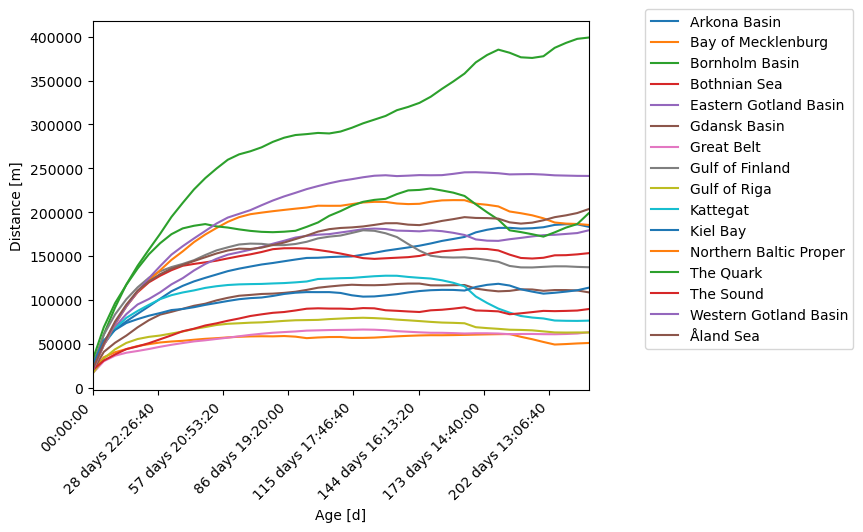

In [128]:
# fig, ax = plt.subplots(111, figsize=(15,10))
p = df_distance_m.plot()
p.legend(loc="best", bbox_to_anchor=(1.1, 1.05))
# p.tick_params("x", rotation=45,)
plt.xticks(rotation=45, ha="right")
# a =print(p.xaxis.get_ticklabels())
# print(p.xaxis.get_majorticklocs())
# p.xaxis.set_major_formatter()
# p.set_xticklabels(labels=np.timedelta64(1, "D")*np.arange(0, 220, 7))
p.set_xlabel("Age [d]")
p.set_ylabel("Distance [m]")
plt.show()

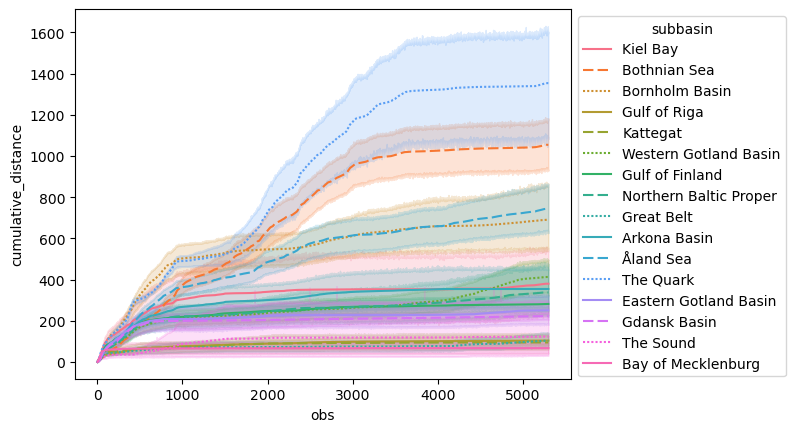

In [ ]:
fig = plt.Figure((15,15))
ax = sns.lineplot(
        data=df, 
        x="obs", y="cumulative_distance",
        hue="subbasin",
        style="subbasin",
        dashes=['', (5, 2), (1, 1)],
)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

<Axes: xlabel='total_distance', ylabel='subbasin'>

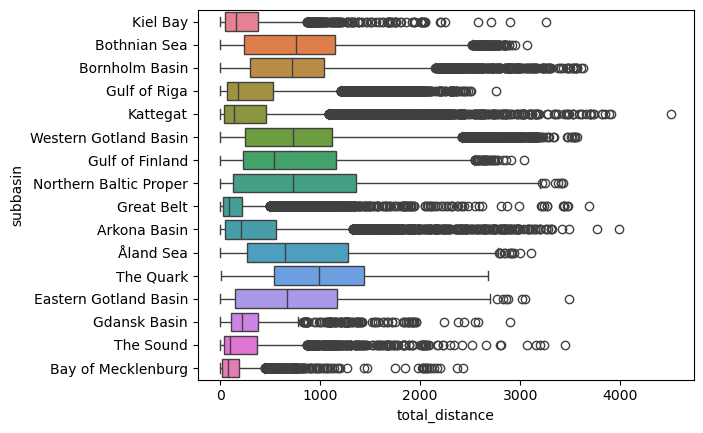

In [103]:
sns.boxplot(df_total, x="total_distance", y="subbasin", hue="subbasin")

In [59]:
basin_names = pd.Index(data=list(subbasin_grouped.groups.keys()), name="subbasins")
basin_idx = pd.Index(data=["trajs", "cells"], name="index")

In [60]:
basins = pd.DataFrame(
        index=basin_names,
        columns=basin_idx,
        data=basin_counts,
)

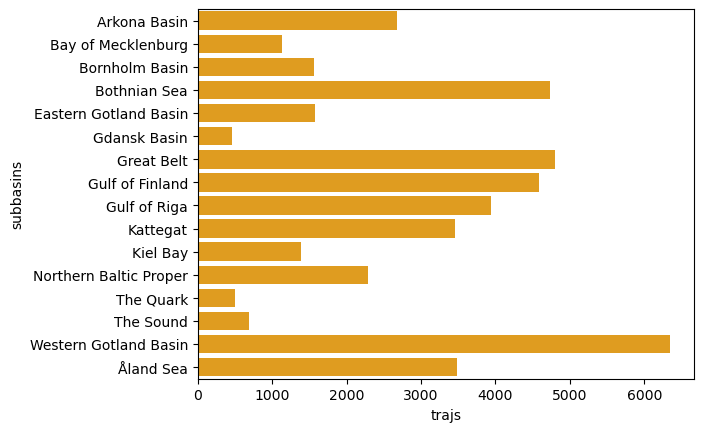

<Axes: xlabel='cells', ylabel='subbasins'>

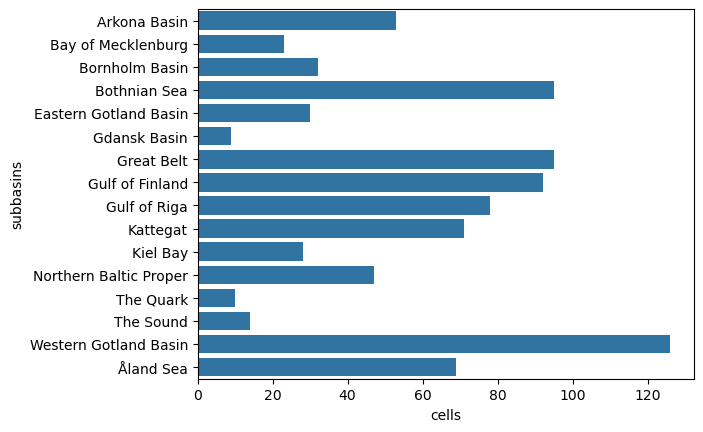

In [61]:
sns.barplot(basins, x="trajs", y="subbasins", color="orange")
plt.show()
sns.barplot(basins, x="cells", y="subbasins")

In [ ]:
mean_total_distance_per_cell = ds_trajectories.total_distance.groupby("cell_code").mean()
mean_total_distance_per_cell

In [ ]:
# open depth files and define depth cmap
path_static_files = Path("/gxfs_work/geomar/smomw122/bsh_operationalmodel_data")
path_static_fine = path_static_files / "static_file_fine"
path_static_coarse = path_static_files / "static_file_coarse"
depth_coarse = xr.open_dataset(path_static_coarse / "H0_file_coarse.nc").H0
depth_fine = xr.open_dataset(path_static_fine / "H0_file_fine.nc").H0
cm_deep = cmocean.cm.deep

In [ ]:
traj_lat = np.concatenate(traj_moving.lat.values)
traj_lon = np.concatenate(traj_moving.lon.values)

traj_lat = traj_lat[np.invert(np.isnan(traj_lat,))]
traj_lon = traj_lon[np.invert(np.isnan(traj_lon,))]